<a href="https://colab.research.google.com/github/falseywinchnet/EpistemicGPT/blob/main/2027GPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ["TORCHINDUCTOR_FREEZE_PCH"] = "1"
# Also force Inductor to use a fresh directory if the previous one is locked
os.environ["TORCHINDUCTOR_CACHE_DIR"] = "/tmp/torch_compile_fresh"

In [57]:
#copyright 2026 joshuah.rainstar@gmail.com
#MIT- take this and use it, but please credit me.
#Version 1.2 EpistemicGPT


import math
import copy
from dataclasses import dataclass
from typing import Optional, Tuple, List
import torch
import torch.nn as nn
import torch.nn.functional as F

class LELU(nn.Module):
    def __init__(self):
        super().__init__()
        self.scale = math.pi / math.sqrt(3.0) #logistic CDF matched scale beats gelu and is less expensive

    def forward(self, x):
        return x * torch.sigmoid(self.scale * x)



class RoPE(nn.Module):
    def __init__(self, dim, max_len=4096):
        super().__init__()
        self.dim = dim
        self.max_len = max_len

        w_max = torch.pi / 2 #highest frequency- one rotation in 4 tokens
        w_min = torch.pi / (max_len) #this sets the lowest scale to that sufficient to resolve needle at depth.
        #most effectively, set your context size to more than you ever intend to handle
        B = 10
        setfreqs_hi = torch.logspace(
                    start=math.log(w_min,B),
                    end=math.log(w_max,B),
                    steps=(dim // 4),
                    base=B
                )


        setfreqs_lo = w_max - torch.logspace(
            start=math.log(w_min,B),
            end=math.log(w_max,B),
            steps=(dim // 4) + 1,
            base=B
        )[:-1] # Drop last to match size and allow a smooth continuation

                # Combine
        setfreqs = torch.cat((setfreqs_hi, setfreqs_lo))
        inv_freq, _ = torch.sort(setfreqs,descending=True) #this give us a sigmoidal distribution of frequencies.
        #many large, many small, few near the midpoint.

        t = torch.arange(max_len).float()
        freqs = torch.einsum('i,j->ij', t, inv_freq)
        self.register_buffer('cos_cached', freqs.cos())
        self.register_buffer('sin_cached', freqs.sin())

    def get_embeddings(self, positions, device):
        positions = positions.clamp(0, self.max_len - 1).long()
        cos = F.embedding(positions, self.cos_cached).unsqueeze(0).unsqueeze(0) # [1, 1, T, D]
        sin = F.embedding(positions, self.sin_cached).unsqueeze(0).unsqueeze(0)
        return cos, sin

    def forward(self, x, positions=None):
        # x: (B, H, T, D) where D = self.dim (head_dim)
        if positions is None:
            T = x.shape[-2]
            positions = torch.arange(T, device=x.device)

        cos, sin = self.get_embeddings(positions, x.device)
        # cos, sin: [1, 1, T, D//2]

        D = x.shape[-1]
        mid = D // 2
        h1 = x[..., :mid]   # first half of dimensions
        h2 = x[..., mid:]   # second half of dimensions

        # Adjacent pairing within each half:
        # h1 pairs: (h1[0],h1[1]), (h1[2],h1[3]), ...
        # h2 pairs: (h2[0],h2[1]), (h2[2],h2[3]), ...
        #
        # h1 gets sign-flipped convention (sin term adds instead of subtracts)
        # h2 gets standard convention
        #
        # This is achieved by negating the "b" element of each pair in h1
        # before feeding into the standard rotation formula.

        # For h1: negate odd-indexed elements, apply rotation, un-negate
        # Equivalent to: the kernel contribution for h1 pairs becomes
        #   S * cos(w*d) + A * sin(w*d)
        # instead of
        #   S * cos(w*d) - A * sin(w*d)

        # Extract paired elements for h1
        h1_a = h1[..., 0::2]   # even indices (the "real" part)
        h1_b = h1[..., 1::2]   # odd indices (the "imaginary" part)

        # Extract paired elements for h2
        h2_a = h2[..., 0::2]
        h2_b = h2[..., 1::2]

        # Split cos/sin for the two halves' frequency ranges
        # First D//4 frequencies go to h1, last D//4 to h2
        n_pairs_per_half = mid // 2  # D//4
        cos1 = cos[..., :n_pairs_per_half]
        sin1 = sin[..., :n_pairs_per_half]
        cos2 = cos[..., n_pairs_per_half:]
        sin2 = sin[..., n_pairs_per_half:]

        # H1: flipped convention (negate b before rotation)
        # Standard rotation on (a, -b):
        #   out_a = a * cos - (-b) * sin = a * cos + b * sin
        #   out_b_neg = a * sin + (-b) * cos = a * sin - b * cos
        # Then un-negate b: out_b = -(a * sin - b * cos) = -a * sin + b * cos
        out_h1_a = h1_a * cos1 + h1_b * sin1
        out_h1_b = -h1_a * sin1 + h1_b * cos1

        # H2: standard convention
        #   out_a = a * cos - b * sin
        #   out_b = a * sin + b * cos
        out_h2_a = h2_a * cos2 - h2_b * sin2
        out_h2_b = h2_a * sin2 + h2_b * cos2

        # Reassemble: interleave a,b back into adjacent pairs
        out_h1 = torch.stack([out_h1_a, out_h1_b], dim=-1).flatten(-2)
        out_h2 = torch.stack([out_h2_a, out_h2_b], dim=-1).flatten(-2)

        return torch.cat([out_h1, out_h2], dim=-1)



class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.act = LELU()
        self.c_proj  = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class MLP_bottle(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd,  config.n_embd//2, bias=config.bias)
        self.act = LELU()
        self.c_proj  = nn.Linear(config.n_embd//2, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class Attention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_heads = config.n_head
        self.n_embd = config.n_embd
        dim = config.n_embd
        self.head_dim = dim // self.n_heads
        self.skew_basis = nn.Parameter(
            torch.randn(self.n_heads, self.head_dim, self.head_dim) * 0.02
        )


        self.q_proj = nn.Linear(dim,dim,bias=False)
        self.v_proj = nn.Linear(dim,dim,bias=False)
        self.o_proj = nn.Linear(dim,dim,bias=False)

        self.o_mlp = MLP(config)
        self.p_mlp = MLP(config)

        nn.init.eye_(self.q_proj.weight) # Identity Init
        self.v_sink_residual = nn.Parameter(torch.ones(1, 1, 1, self.head_dim))
        self.v_sink_basis = nn.Parameter(torch.ones(1, self.n_heads, 1, self.head_dim))

        self.mask = None #set in GPT main at model time to ensure its on GPU
        self.rope = config.rope
        limit = config.block_size // 2

        self.sd_alpha = 0.3
        self.sd_sigma = config.block_size / 2.0
        alphas = torch.linspace(0, 1, self.n_heads).view(1, self.n_heads, 1, 1)
        self.register_buffer('k_alpha', alphas)
        self.p_skew_basis = nn.Parameter(
            torch.randn(self.n_heads, self.head_dim, self.head_dim) * 0.02
        )


    def get_p_matrix(self):
        skew = self.p_skew_basis - self.p_skew_basis.transpose(-1, -2)
        return torch.matrix_exp(skew)

    def get_orthogonal_matrix(self):
        # A = M - M.T (Skew symmetric)
        # We broadcast the transpose over the last two dims
        skew = self.skew_basis - self.skew_basis.transpose(-1, -2)

        # Matrix Exp for each head independently
        # Result: [H, D_h, D_h]
        return torch.matrix_exp(skew)

    def forward(self, x):
        B, T, C = x.shape
        H, D = self.n_heads, self.head_dim

        # Get per-head rotations
        Rs = self.get_orthogonal_matrix() # [H, D, D]

        # 1. Reshape q_proj weight to [H, D_h, Dim]
        W_q = self.q_proj.weight.view(self.n_heads, self.head_dim, -1)

        # 2. Rotate each head's slice of the weight matrix
        # [H, D, D] @ [H, D, Dim] -> [H, D, Dim]
        W_k_heads = Rs @ W_q

        # 3. Flatten back to [Dim, Dim] for the linear layer
        # This effectively constructs a Block-Diagonal W_k
        W_k = W_k_heads.view(-1, self.n_embd)

        q = self.q_proj(x).view(B, T, H, D).transpose(1, 2)
        k = F.linear(x, W_k).view(B, T, H, D).transpose(1, 2)


        v = self.v_proj(x).view(B, T, H, D).transpose(1, 2)


        q = F.rms_norm(q, (D,)) #never ever norm k, you stupid fuck

        q = self.rope(q)
        k = self.rope(k)

        # Soft Attention
        scores = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(D))

        mask = self.mask[:, :, :T, :T]

        soft_scores = F.softplus(scores)
        # STE: Forward sets small/neg values to 0, Backward ignores the zeroing
        # Values < 1e-6 do not participate in mass/scaling but receive gradients
        threshold = 1e-6
        pruned_scores = torch.where(soft_scores < threshold, torch.zeros_like(soft_scores), soft_scores)
        soft_scores = soft_scores + (pruned_scores - soft_scores).detach()

        soft_scores = soft_scores.masked_fill(mask == 0, 0.0) #prevent cheating here

        if self.training:
            # Create Distance Matrix [T, T]
            # dist[i, j] = i - j
            # We only care about positive distances (j <= i), which causal mask handles
            indices = torch.arange(T, device=x.device)
            dist = indices.view(-1, 1) - indices.view(1, -1)

            # Gaussian Decay Profile
            # P(drop) is high when dist is small (Recent)
            # P(drop) is low when dist is large (Distant)
            # We clamp dist to 0 to avoid NaNs, though masking handles it


            # Broadcast probabilities to batch/heads [1, 1, T, T]
            dist = dist.float().clamp(min=0)
            drop_probs = self.sd_alpha * torch.exp(-(dist**2) / (2 * self.sd_sigma**2))

            # Align dimensions: [1, 1, T, T]
            drop_probs = drop_probs.unsqueeze(0).unsqueeze(0)

            #dont allow damage to the first half, regardless
            #limited suppot positions do not get eroded
            limit = T // 2
            absolute_cutoff_mask = (dist > limit)
            drop_probs = drop_probs.masked_fill(absolute_cutoff_mask, 0.0)
            #Expand BEFORE sampling to ensure atomic independence
            # We must explicitly expand to [B, H, T, T] so Bernoulli rolls
            # a unique die for every single head and batch item.
            drop_probs_expanded = drop_probs.expand(B, H, T, T)

            # Generate Bernoulli Mask on the full tensor
            keep_mask = torch.bernoulli(1.0 - drop_probs_expanded).bool()

            # Apply Dropout
            soft_scores = soft_scores.masked_fill(~keep_mask, 0.0)
            #what this does is force attention to learn deeper patterns.
            #it also dramatically improves needles- it finds needles with same num batches,
            #despite randomly hiding needles. so it technically sees needle far sooner.


        soft_sums = soft_scores.sum(dim=-1, keepdim=True)
        scale = torch.clamp(1.0 / (soft_sums + 1e-6), max=1.0)
        attn = soft_scores * scale
        attn = torch.nan_to_num(attn, nan=0.0)

            # ===== Replace everything from y_context = attn @ v onward =====

        y_context = attn @ v  # (B, H, T, D)

        # === Mixing tensor: variance of the attended distribution ===
        v_sq = attn @ (v * v)  # E[v^2] under attention weights
        mix_variance = F.softplus(v_sq - y_context * y_context)  # Var[v] per dim, (B, H, T, D)

        # Project mix_variance into mixing directions
        # mix_proj learns to read the variance profile and output the principal mixing axis
        mix_dir = F.normalize(mix_variance, dim=-1)

        # === Residual sink ===
        current_mass = attn.sum(dim=-1, keepdim=True)
        residual_weight = 1.0 - F.sigmoid(current_mass)
        y_res = residual_weight * self.v_sink_residual

        # === XSA ===
        vn = F.normalize(v, dim=-1)
        y_context = y_context - (y_context * vn).sum(dim=-1, keepdim=True) * vn

        y = F.rms_norm(y_context, (D,)) +self.v_sink_basis + y_res
        # y is (B, H, T, D)

        # === O/P decomposition along mixing tensor eigenvectors ===
        # Decompose y into component along mix_dir and component orthogonal to it
        # mix_dir is the dominant eigenvector of the mixing stress
        y_along = (y * mix_dir).sum(dim=-1, keepdim=True) * mix_dir  # projection onto mixing axis
        y_ortho = y - y_along  # complement

        # Flatten both to (B, T, C) for projection
        y_along_flat = y_along.transpose(1, 2).contiguous().view(B, T, -1)
        y_ortho_flat = y_ortho.transpose(1, 2).contiguous().view(B, T, -1)

        # O projects the component along the mixing direction
        # P (orthogonal rotation of O) projects the orthogonal complement
        Rs_p = self.get_p_matrix()  # (H, D, D)
        W_o_heads = self.o_proj.weight.view(self.n_heads, self.head_dim, -1)
        W_p_heads = Rs_p @ W_o_heads
        W_p = W_p_heads.view(-1, self.n_embd)

        o_out = self.o_proj(y_along_flat)      # mixing-axis content through O
        o_out = self.o_mlp(o_out)
        p_out = F.linear(y_ortho_flat, W_p)    # orthogonal content through P
        p_out = self.p_mlp(p_out)

        return o_out + p_out


def norm(x):
    return F.rms_norm(x, (x.size(-1),))

class Block(nn.Module):
    def __init__(self, config, block_idx):
        super().__init__()
        self.attn = Attention(config)
        self.attn_dir = MLP_bottle(config)
        self.config = config

    def forward(self, x):

        a = norm(x)
        z = self.attn(a)
        vn = F.normalize(self.attn_dir(a), dim=-1)
        q = x - (x * vn).sum(dim=-1, keepdim=True) * vn
        x = q + z

        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 66 #shakespeare
    n_layer: int = 1
    n_head: int = 6

    n_embd: int = 192 #recommend 32 min per head
    dropout: float = 0.0
    bias: bool = False
    rope: nn.Module = None
    bottle: nn.Module = None
    device: str = "cuda"

class SoftplusCELoss(nn.Module):
    def __init__(self, ignore_index=-1, label_smoothing=0.0):
        super().__init__()
        self.ignore_index = ignore_index
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        # logits: (B, V) or (B, T, V)
        # targets: (B,) or (B, T)
        flat_logits = logits.view(-1, logits.size(-1))
        flat_targets = targets.view(-1)

        mask = flat_targets != self.ignore_index
        flat_logits = flat_logits[mask]
        flat_targets = flat_targets[mask]

        if flat_targets.numel() == 0:
            return flat_logits.sum() * 0.0

        # softplus "probabilities" -- same mechanism as your attention
        sp = F.softplus(flat_logits)

        threshold = 1e-6
        pruned = torch.where(sp < threshold, torch.zeros_like(sp), sp)
        sp = sp + (pruned - sp).detach()  # STE

        sp_sum = sp.sum(dim=-1, keepdim=True)
        scale = torch.clamp(1.0 / (sp_sum + 1e-6), max=1.0)
        probs = sp * scale  # sub-unity simplex

        # gather target probs
        target_probs = probs.gather(1, flat_targets.unsqueeze(1)).squeeze(1)

        # NLL on the softplus-normalized probs
        loss = -torch.log(target_probs + 1e-8)

        if self.label_smoothing > 0.0:
            # smooth term: average negative log-prob across vocab
            smooth_loss = -torch.log(probs + 1e-8).mean(dim=-1)
            loss = (1.0 - self.label_smoothing) * loss + self.label_smoothing * smooth_loss

        return loss.mean()

class SubspaceUnembed(nn.Module):
    def __init__(self, d_model, vocab_size, n_slices=4):
        super().__init__()
        self.n_slices = n_slices
        self.sub_d = d_model // n_slices
        assert d_model % n_slices == 0

        self.dir_nets = nn.ModuleList([
            nn.Linear(d_model, d_model, bias=False)
            for _ in range(n_slices)
        ])
        self.projs = nn.ModuleList([
            nn.Linear(d_model, vocab_size, bias=False)
            for _ in range(n_slices)
        ])
        self.residual_proj = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, h):
        logits = 0
        residual = h
        for i in range(self.n_slices):
            vn = F.normalize(self.dir_nets[i](h), dim=-1)
            component = (residual * vn).sum(dim=-1, keepdim=True) * vn
            residual = residual - component
            logits = logits + self.projs[i](component)

        logits = logits + self.residual_proj(residual)
        return logits



class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.rope = RoPE(config.n_embd // config.n_head, max_len=config.block_size)
        self.config.rope = self.rope

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(self.config,i) for i in range(config.n_layer)]),
        ))
        mask_tensor = torch.tril(torch.ones(config.block_size, config.block_size)).view(1, 1, config.block_size, config.block_size).to(device=self.config.device)
        self.register_buffer("mask", mask_tensor)
        for block in self.transformer.h:
          block.attn.mask = self.mask #set here
        self.criterion = SoftplusCELoss(ignore_index=-1)
        self.lm_head = SubspaceUnembed(config.n_embd, config.vocab_size)

        print("number of parameters: %.2fM" % (self.get_num_params()/1e6,))

    def get_num_params(self, non_embedding=True):
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wte.weight.numel()
        return n_params

    def forward(self, idx, targets=None):
        b, T = idx.size()
        x = self.transformer.wte(idx)
        x = norm(x)

        for i, block in enumerate(self.transformer.h):
            x = block(x)


        if targets is not None:
            logits = self.lm_head(x)
            loss = self.criterion(logits, targets)
        else:
            logits = self.lm_head(x[:, [-1], :])
            loss = None

        return logits, loss



d=256, slices=2: e[0]=10.373 e[-1]=10.373 comp_fracs=[0.04904991760849953, 0.050086524337530136] resid_norm=15.8383 catchall=10.2100
d=256, slices=4: e[0]=10.373 e[-1]=10.373 comp_fracs=[0.05158469080924988, 0.04755840077996254, 0.04636199399828911, 0.04163315147161484] resid_norm=15.8602 catchall=10.2099
d=256, slices=8: e[0]=10.373 e[-1]=10.373 comp_fracs=[0.048091113567352295, 0.05021592974662781, 0.05518804118037224, 0.04707280546426773, 0.054379962384700775, 0.03930293396115303, 0.04799005016684532, 0.05012557655572891] resid_norm=15.7293 catchall=10.2121
d=256, slices=16: e[0]=10.373 e[-1]=10.373 comp_fracs=[0.0484064519405365, 0.04617362469434738, 0.045136116445064545, 0.04957684129476547, 0.0555817149579525, 0.04785165935754776, 0.05937158688902855, 0.05301118642091751, 0.048105839639902115, 0.049827151000499725, 0.053271934390068054, 0.04882698506116867, 0.04624946787953377, 0.05168216675519943, 0.052524957805871964, 0.045655567198991776] resid_norm=15.4562 catchall=10.2178
d=

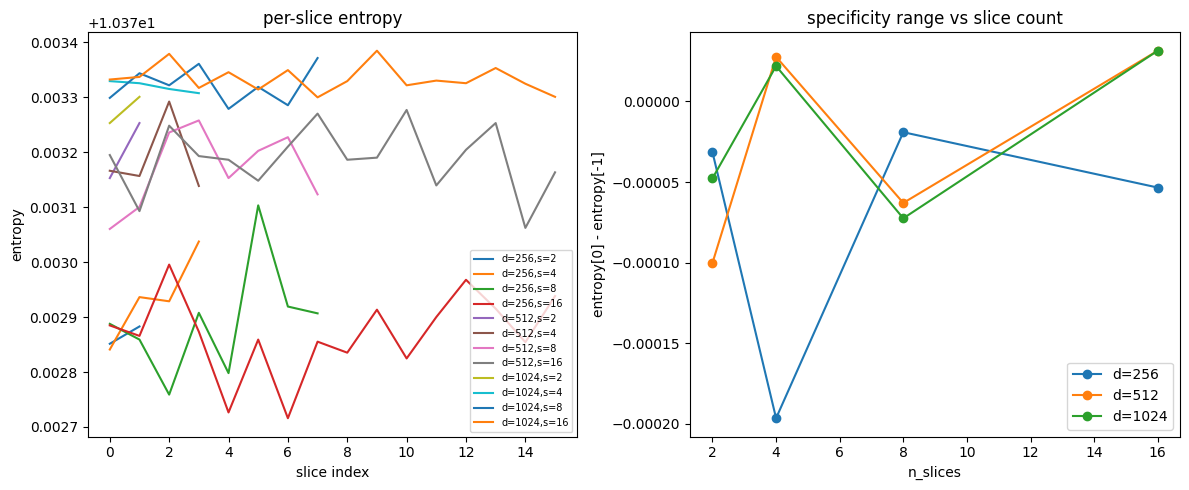

In [56]:
import torch
import torch.nn.functional as F
from torch import nn
import matplotlib.pyplot as plt

def slice_entropy_profile(model, h, temperature=1.0):
    if h.dim() == 1:
        h = h.unsqueeze(0)

    entropies = []
    component_fracs = []   # |component| / |residual| -- surfaces starvation
    residual = h.clone()

    for i in range(model.n_slices):
        # fix: use residual not h
        vn = F.normalize(model.dir_nets[i](residual), dim=-1)
        component = (residual * vn).sum(dim=-1, keepdim=True) * vn

        # surface component fraction before subtracting
        frac = (component.norm(dim=-1) / (residual.norm(dim=-1) + 1e-12)).mean().item()
        component_fracs.append(frac)

        residual = residual - component

        logit_slice = model.projs[i](component) / temperature
        probs = F.softmax(logit_slice, dim=-1)
        entropy = -(probs * (probs + 1e-12).log()).sum(dim=-1).mean().item()
        entropies.append(entropy)

    residual_norm = residual.norm(dim=-1).mean().item()

    # surface the double-count: what does projs[-1](residual) add?
    catchall_logits = model.projs[-1](residual) / temperature
    catchall_probs = F.softmax(catchall_logits, dim=-1)
    catchall_entropy = -(catchall_probs * (catchall_probs + 1e-12).log()).sum(dim=-1).mean().item()

    return entropies, component_fracs, residual_norm, catchall_entropy


def sweep_slices_and_dims(vocab_size=32000, d_models=[256, 512, 1024],
                           slice_counts=[2, 4, 8, 16], n_samples=64):
    results = {}

    for d_model in d_models:
        for n_slices in slice_counts:
            if d_model % n_slices != 0:
                continue
            model = SubspaceUnembed(d_model, vocab_size, n_slices=n_slices)
            model.eval()

            h = torch.randn(n_samples, d_model)
            with torch.no_grad():
               entropies, component_fracs, res_norm, catchall_entropy = slice_entropy_profile(model, h)

            key = (d_model, n_slices)
            results[key] = {
                "entropies": entropies,
                "component_fracs": component_fracs,
                "residual_norm": res_norm,
                "catchall_entropy": catchall_entropy,
                "entropy_drop": entropies[0] - entropies[-1],
                "mean_entropy": sum(entropies) / len(entropies),
            }
            print(f"d={d_model}, slices={n_slices}: "
                  f"e[0]={entropies[0]:.3f} e[-1]={entropies[-1]:.3f} comp_fracs={component_fracs} "
                  f"resid_norm={res_norm:.4f} catchall={catchall_entropy:.4f}")

    return results


def plot_entropy_profiles(results):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for (d_model, n_slices), v in results.items():
        axes[0].plot(v["entropies"], label=f"d={d_model},s={n_slices}")
    axes[0].set_xlabel("slice index")
    axes[0].set_ylabel("entropy")
    axes[0].set_title("per-slice entropy")
    axes[0].legend(fontsize=7)

    # entropy drop vs n_slices, colored by d_model
    d_models_seen = sorted(set(k[0] for k in results))
    for d in d_models_seen:
        xs = sorted(k[1] for k in results if k[0] == d)
        ys = [results[(d, s)]["entropy_drop"] for s in xs]
        axes[1].plot(xs, ys, marker="o", label=f"d={d}")
    axes[1].set_xlabel("n_slices")
    axes[1].set_ylabel("entropy[0] - entropy[-1]")
    axes[1].set_title("specificity range vs slice count")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("slice_entropy_profile.png", dpi=150)
    plt.show()


if __name__ == "__main__":
    results = sweep_slices_and_dims()
    plot_entropy_profiles(results)

In [2]:


import requests, os

base_url = "https://huggingface.co/datasets/cambridge-climb/BabyLM/resolve/main/clean/10M/"
target_dir = "./babylm_10m_cleaned"
os.makedirs(target_dir, exist_ok=True)

file_names = [
    "aochildes.txt",
    "cbt.txt",
    "children_stories.txt",
    "gutenberg.txt",
    "qed.txt",
    "simple_wikipedia.txt",
    "switchboard.txt",
    "wikipedia.txt"
]

# Optional addition: Shakespeare from another dataset
shakespeare_url = "https://raw.githubusercontent.com/karpathy/char-rnn/refs/heads/master/data/tinyshakespeare/input.txt"
shakespeare_fname = "shakespeare.txt"

# Combined download logic
all_files = [(base_url + fname, fname) for fname in file_names]
all_files.append((shakespeare_url, shakespeare_fname))  # Add Shakespeare


# Download loop
for url, fname in all_files:
    out_path = os.path.join(target_dir, fname)
    print(f"📥 Downloading {fname}...")
    resp = requests.get(url)
    if resp.status_code == 200:
        with open(out_path, "w", encoding="utf-8") as f:
            f.write(resp.text)
    else:
        print(f"❌ Failed to download {fname} ({resp.status_code})")

print(f"✅ Done. Files saved to {target_dir}")

📥 Downloading aochildes.txt...
📥 Downloading cbt.txt...
📥 Downloading children_stories.txt...
📥 Downloading gutenberg.txt...
📥 Downloading qed.txt...
📥 Downloading simple_wikipedia.txt...
📥 Downloading switchboard.txt...
📥 Downloading wikipedia.txt...
📥 Downloading shakespeare.txt...
✅ Done. Files saved to ./babylm_10m_cleaned


In [3]:
import os
import pickle
import numpy as np

# === Paths ===
source_dir = "./babylm_10m_cleaned"
out_dir    = "./babylm_char_tokenized"
os.makedirs(out_dir, exist_ok=True)

file_names = [
    "shakespeare.txt"#,"aochildes.txt", "cbt.txt", "children_stories.txt", "gutenberg.txt",
    #"qed.txt", "simple_wikipedia.txt", "switchboard.txt", "wikipedia.txt"
]

# === Load and split ===
train_texts, val_texts = [], []
char_set = set()

for fname in file_names:
    with open(os.path.join(source_dir, fname), encoding="utf-8") as f:
        lines = f.readlines()
        n = len(lines)
        split = int(0.9 * n)
        train_part = "".join(lines[:split])
        val_part   = "".join(lines[split:])
        train_texts.append(train_part)
        val_texts.append(val_part)
        char_set.update(train_part)
        char_set.update(val_part)

full_train = "\n".join(train_texts)
full_val   = "\n".join(val_texts)

# === Final vocab ===
char_set = sorted(set(char_set))
vocab_chars = ["<unk>"] + [c for c in char_set if c != "<unk>"]

stoi = {ch: i for i, ch in enumerate(vocab_chars)}
itos = {i: ch for ch, i in stoi.items()}

# === Encode function ===
def encode(text):
    return [stoi.get(c, 0) for c in text]

train_ids = np.array(encode(full_train), dtype=np.uint16)
val_ids   = np.array(encode(full_val),   dtype=np.uint16)

# === Save ===
train_ids.tofile(os.path.join(out_dir, "train.bin"))
val_ids.tofile(os.path.join(out_dir, "val.bin"))

with open(os.path.join(out_dir, "meta.pkl"), "wb") as f:
    pickle.dump({
        "vocab_size": len(stoi),
        "stoi": stoi,
        "itos": itos
    }, f)

print(f"✅ Char tokenizer finalized.")
print(f"🧾 Train tokens: {len(train_ids)} | Val tokens: {len(val_ids)}")
print(f"🔤 Vocab size: {len(stoi)}")

✅ Char tokenizer finalized.
🧾 Train tokens: 1016242 | Val tokens: 99152
🔤 Vocab size: 66


In [ ]:
import shutil, os, tempfile

cache_dir = os.path.join(tempfile.gettempdir(), "torchinductor_joshuahkuttenkuler")
shutil.rmtree(cache_dir, ignore_errors=True)
print("cleared", cache_dir)

cleared /var/folders/7_/98nk8q255lxf2kbxm92j37rh0000gn/T/torchinductor_joshuahkuttenkuler


In [63]:
import os
import pickle
import numpy as np
from torch.utils.data import DataLoader, Dataset
import torch
from torch import nn
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

# === Config ===
data_dir = "./babylm_char_tokenized"  # <- char-tokenized data
block_size = 1024
batch_size = 8

# === Load tokenizer metadata ===
with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)
vocab_size = meta['vocab_size']

# === Load mmap edata (char-level tokens, uint16) ===
train_ids = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
val_ids   = np.memmap(os.path.join(data_dir, 'val.bin'),   dtype=np.uint16, mode='r')

# === Efficient GPU Batch Sampler ===
class GPUBatchDataset(Dataset):
    def __init__(self, mmap_file, block_size, batch_size, device, jitter=63, p_aligned=0.5, pad_len=0):
        self.data = mmap_file
        self.block_size = block_size
        self.batch_size = batch_size
        self.device = device
        self.pad_len = int(pad_len)
        self.sample_len = self.block_size + self.pad_len  # X length
        self.total = len(self.data) - self.sample_len - 1
        self.n_blocks = self.total // self.sample_len
        self.jitter = int(jitter)          # small random offset added to aligned start
        self.p_aligned = float(p_aligned)  # mix aligned and jittered

    def __len__(self):
        return self.total // self.batch_size

    def __getitem__(self, idx):
        X = np.empty((self.batch_size, self.sample_len), dtype=np.int64)
        Y = np.empty((self.batch_size, self.block_size), dtype=np.int64)

        for i in range(self.batch_size):
            # === THE FIX ===
            # Pick a TRULY random start index anywhere in the file
            # No grid, no alignment, no "base_block"
            start = np.random.randint(0, self.total)

            X[i] = self.data[start : start + self.sample_len]
            Y[i] = self.data[start + 1 + self.pad_len : start + 1 + self.pad_len + self.block_size]

        return (
            torch.from_numpy(X).to(self.device, non_blocking=True),
            torch.from_numpy(Y).to(self.device, non_blocking=True)
        )


config = GPTConfig(
    vocab_size=len(stoi),
    n_layer=4,
    n_embd=192,
    n_head=6,
    block_size=block_size,
    device = device
)
train_dataset = GPUBatchDataset(train_ids, block_size, batch_size, device, pad_len=0)
# === DataLoader ===
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)
model = GPT(config)
#torch.compiler.reset()
model = torch.compile(model)
model = model.to(device)


number of parameters: 1.15M


In [ ]:
state_dict = torch.load("overfitshakespeare_tiny.pt")
model.load_state_dict(state_dict, strict=True) # strict=True confirms the match is perfect
print("Weights loaded successfully.")

In [46]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params}")

Total trainable parameters: 35456


In [64]:
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
losses = []
def train_epoch():
    model.train()
    itera = 0
    total_loss = 0
    for xb, yb in train_loader:
          xb, yb = xb[0], yb[0]  # unwrap batch dimension
          optimizer.zero_grad()
          logits, loss = model(xb, yb)
          loss = loss
          loss.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
          optimizer.step()
          total_loss += loss.item()
          losses.append(loss.item())
          print(itera, loss.item())
          itera = itera + 1
    return total_loss / len(train_loader)

# === Run Training ===
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

0 4.2570390701293945
1 3.5501835346221924
2 3.400191307067871
3 3.1953084468841553
4 3.146279811859131
5 3.0070605278015137
6 2.9858388900756836
7 2.9068524837493896
8 2.831756830215454
9 2.743313789367676
10 2.68928861618042
11 2.6407113075256348
12 2.6545450687408447
13 2.586167335510254
14 2.5826072692871094
15 2.5610082149505615
16 2.568434476852417
17 2.551490068435669
18 2.5502021312713623
19 2.5593719482421875
20 2.5174672603607178
21 2.5544486045837402
22 2.50537371635437
23 2.5202579498291016
24 2.539942741394043
25 2.5667152404785156
26 2.5177690982818604
27 2.524595022201538
28 2.497523784637451
29 2.5219056606292725
30 2.493267059326172
31 2.493187189102173
32 2.493217945098877
33 2.4954514503479004
34 2.531601905822754
35 2.505488634109497
36 2.5007431507110596
37 2.4913835525512695
38 2.5062031745910645
39 2.4672322273254395
40 2.4855685234069824
41 2.4826903343200684
42 2.484079122543335
43 2.4993951320648193
44 2.4884719848632812
45 2.474449634552002
46 2.50204086303710

KeyboardInterrupt: 

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import umap # pip install umap-learn

def visualize_organelle(model):
    # 1. Collect all MLP Neurons ("Detectors")
    # In GPT, the MLP up-projection (c_fc) reads from the embedding space.
    # Each row is a "neuron" looking for a specific direction in 128-dim space.

    all_neurons = []
    layer_labels = []

    print("Extracting neurons...")
    for i, block in enumerate(model.transformer.h):
        # Shape: [4 * n_embd, n_embd] -> [512, 128] for your config
        # We view these as 512 distinct vectors in 128-dim space
        weights = block.ffn.c_fc.weight.detach().cpu().numpy()
        all_neurons.append(weights)
        layer_labels.append(np.full(weights.shape[0], i)) # Track which layer owns the neuron

    # Concatenate to shape [Total_Neurons, n_embd]
    # For 4 layers * 512 neurons = 2048 points
    X = np.vstack(all_neurons)
    labels = np.concatenate(layer_labels)

    # 2. UMAP Projection (The "Organelle" Generator)
    # n_neighbors: Controls local vs global structure.
    #   Low (5-15) = fragmentation (many tiny blobs).
    #   High (50-100) = global shape (one big connected organelle).
    # min_dist: Controls how tightly points pack together.
    print("Computing 3D Manifold (this may take a moment)...")
    reducer = umap.UMAP(
        n_neighbors=5,
        min_dist=0.1,
        n_components=5,
        metric='cosine' # Cosine is critical for high-dim semantics
    )
    embedding = reducer.fit_transform(X)

    # 3. Visualization
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Color map matches the layer depth
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        embedding[:, 2],
        c=labels,
        cmap='plasma',
        s=10,
        alpha=0.6,
        edgecolor='none'
    )

    # Styling to look like the "Twitter render"
    ax.set_facecolor('white')
    ax.grid(False)
    ax.set_title("Neural Organelle: MLP Key Vectors by Layer", fontsize=15)

    # Add a color bar indicating depth
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.6)
    cbar.set_label('Layer Depth')

    # Remove axis ticks for cleaner look
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    plt.tight_layout()
    plt.show()

# Run it
visualize_organelle(model)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.


KeyboardInterrupt



In [11]:
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

0 1.9921748638153076
1 1.9920295476913452
2 1.9971251487731934
3 2.0339670181274414
4 1.9319885969161987
5 1.96665620803833
6 1.8649084568023682
7 1.9397192001342773
8 1.984774112701416
9 1.9485883712768555
10 1.912592887878418
11 1.991931438446045
12 2.0124123096466064
13 1.9731205701828003
14 1.983176589012146
15 1.9877309799194336
16 1.9700108766555786
17 1.9645001888275146
18 2.020998954772949
19 1.9723389148712158
20 1.9746849536895752
21 1.9461990594863892
22 2.0126116275787354
23 2.00266695022583
24 1.9649267196655273
25 1.9592804908752441
26 1.991256833076477
27 2.003382682800293
28 1.9830386638641357
29 1.997788667678833
30 1.9808731079101562
31 1.9727625846862793
32 1.9156875610351562
33 1.978927493095398
34 1.9290274381637573
35 1.9716947078704834
36 1.999273419380188
37 1.9703905582427979
38 1.9799143075942993
39 1.9790338277816772
40 1.9744510650634766
41 1.9782665967941284
42 1.9843953847885132
43 1.926651954650879
44 1.986689805984497
45 1.9343173503875732
46 1.945989608

KeyboardInterrupt: 

In [ ]:
%matplotlib inline


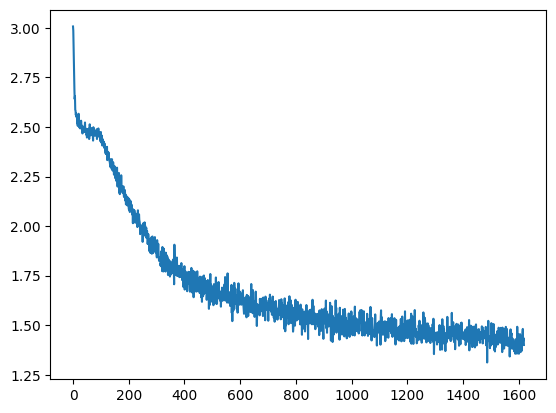

In [66]:
from matplotlib import pyplot as plt

plt.plot(losses[5:])
plt.show()

In [65]:
import numpy as np
import torch
import torch.nn.functional as F

@torch.no_grad()
def eval_bits_per_char(model, val_ids, block_size=1024, max_batches=200, device=None):
    """
    Computes BPC and PPL on random contiguous slices.
    Assumes ?1 the loss returned by model(x, y) is mean NLL per token.
    """
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    total_nll_nat = 0.0
    total_tokens = 0

    for _ in range(max_batches):
        if len(val_ids) <= block_size + 1:
            break

        start = np.random.randint(0, len(val_ids) - block_size - 1)
        x = torch.tensor(val_ids[start:start+block_size], dtype=torch.long, device=device)[None, :]
        y = torch.tensor(val_ids[start+1:start+block_size+1], dtype=torch.long, device=device)[None, :]

        # IMPORTANT: pass y so the model returns a sequence loss
        logits, loss = model(x, y)
        loss=None
        # If model doesn’t return loss for some reason, compute it safely
        if loss is None:
            # Handle both possible logits shapes
            logits, _ = model(x, y)
            if logits.dim() == 3 and logits.size(1) == x.size(1):
                loss = model.criterion(logits, y)
                nll_nat = loss.item()
                tokens = x.numel()
        else:
            # ?1 assume this is mean NLL per token (standard)
            nll_nat = float(loss.item())
            tokens = x.numel()  # B * T

        total_nll_nat += nll_nat * tokens
        total_tokens  += tokens

    if total_tokens == 0:
        return float("nan"), float("nan")

    avg_nll_nat = total_nll_nat / total_tokens
    bpc = avg_nll_nat / np.log(2.0)
    ppl = float(np.exp(avg_nll_nat))
    return bpc, ppl,avg_nll_nat

bpc, ppl ,ce = eval_bits_per_char(model, val_ids, block_size=1024, max_batches=200, device=device)
print("BPC:", bpc, "Perplexity:", ppl, "VAL LOSS:", ce)


BPC: 2.403724147293725 Perplexity: 5.291673860321225 VAL LOSS: 1.6661346155405043


'''
Negative log-likelihood (NLL): The metric underneath both BPC and PPL is the average negative log probability assigned to the true next token. Lower NLL means the model is assigning higher probability to correct targets → better performance.

BPC = NLL in bits per token. Lower BPC means fewer bits are needed to encode the text, i.e. the model compresses language better. A perfect model would reach 0.0 BPC.

PPL = exp(NLL). It represents the "effective branching factor" (how many equally likely next tokens the model is as uncertain between). Lower perplexity means the model is more confident and accurate. A perfect model would reach 1.0 PPL.
Models with <100k parameters usually collapse to gibberish or never beat 5-gram.
BPC of NGRAM is ~3.5-4
'''

In [69]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def softplusmax(logits, temperature=1.0):
    sp = F.softplus(logits / temperature)
    sp = torch.where(sp < 1e-6, torch.zeros_like(sp), sp)
    sp_sum = sp.sum(dim=-1, keepdim=True)
    return sp * torch.clamp(1.0 / (sp_sum + 1e-6), max=1.0)

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = softplusmax(last_logits)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET: I love"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=1.0
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET: I love you his mind,
And chidinging some I feit, and my lord;
And the rogether barest thou were stard
That shut shall me hurt not other's bring.
What wert 'tis rich a bash an end side prettyes
Since whither draws!

HENRY BOLIRather, prince, my older stir,
For be sakel as I wot late in my join,
Or hatresty find be this fears served to him.

LONNTES:
Ay,
Master your bonw to a more a camplace:
My lordst greyher daughter's helt hour last,
And tell the fleet flai mine earthly doing;
As or a top; which are gifter the toptre's hand;
Be goeth an march as treate, our fault,
Upon't that whose regaled so braughter.
Now hants thy earthly doubt set we do her
Most being live burn'd by son in their king.
They mayor though night bone and walking fair;
Now to be me to Ambunes, I would not him.
Though a very knee poor own shadeful title;
Nor one extreme be runousl tenting butchery.
Madam, sir.

BRUTUS:
Good Aurber, strink me hither' of a drucks not sake;
And I pro

In [ ]:
prompts = [
    "ROMEO: Juliet, do you love me?  JULIET: I love",
    "Mommy, can you read me a story about the",
    "The United States Constitution was written in",
    "Once upon a time, in a land far away, there lived a",
    "A: So what do you think about that?  B: Well, I",
    "The process of photosynthesis allows plants to",
    "Chapter 1.  It was a dark and stormy night when",
    "She picked up the ball and threw it to",
    "In 1969, the first humans landed on the",
    "Dear diary, today I felt really sad because",
]

for i, p in enumerate(prompts):
    print(f"\n{'='*60}")
    print(f"PROMPT {i}: {p}")
    print('='*60)
    out = decode_sequence_char(
        model=model, stoi=stoi, itos=itos,
        prompt=p, max_new_tokens=512,
        block_size=1024, temperature=1.0
    )
    print(out)


PROMPT 0: ROMEO: Juliet, do you love me?  JULIET: I love
ROMEO: Juliet, do you love me?  JULIET: I love Marcius? O me, bo,
Still Consoon
Shall tell the staff with your ancient wiverpool! And that ever thoughts to packit,
My open's wisdom away. Your lossing and shirling
Mass ofress I have the aboking-95, my children!
He prays what is stumbling to doing fortio,
To node, sir, granted it as from
since I have asked impression of Yorld's death.

ISABELLO:
Your blood would live in many markino, province, by the Arms,
Unpeal emonitors.
I couldn't have the notes on the foeding,
With Rome to be thy namelias--

BULINA:

PROMPT 1: Mommy, can you read me a story about the
Mommy, can you read me a story about the lord.
Here's your death, you are unconstant, none,
That's one man's heart and no opens for torsia bay.

Nutiçueli, and when the north of situology the mennistration
5 move that internal rockfooty than one dark nature!
Freddy ' Tyrand leaves for your beggars:
He do swungs
Of by the country,

In [70]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = torch.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET:"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=0.00001
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET:
The shall be the shall be the shall be the shall be the shall be the shall be the shall be the shall be the shall be the served the shall the serve the shame,
And the shall the shall be the shall be the shall be the shall be the shall be the shall be the shall the shall be the shall be the served the strength the serves to the serve the shall the shall be the serves to the serve the shall the shall be the shall the shall be the serve the serves the shall the shall be the shall be the serve the serves the shall the shall be the shall be the shall the shall be the serve the serve the shall the shall be the shall the serve the seast the shall be the shall the shall be the shall the shall be the shall be the serve the shame,
And the shall the shall be the shall be the shall the serve the shall the serve the shall the shall be the shall the shall the serve the shall be the shall the serve the seast the serves the shall the shall the shall be the shall

In [72]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = torch.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET:"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=3.0
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET:' is unha, ,xirtRrtl.

BUNHASAl:
Senten me shided
Thi prozm'lQ towy?Bth Hesrt-good.

NUTIO:
I night Clizenvarl!;Fo;neoble hast!:
I seeky the casqLallopineop.

CAMILLO:
It is the maruatern fe; le?

She's readeo!

LADOUP:
I shapeign-otme-zFI, m. Follows Juliet,
Thqueenh,ybutMist boour KiNG-lough, a'PastchWenryl;
And the eb dibmrc
PrPtreadqdot-fopd impor
Ocvad! what ofTJU :rley! Ok;Sanniam not radma; fope u'l!
comman'd queen suchoim;'tfy love! whyinR,ro: mineNR had,
Swnive F.

BENLAGONUS:
Jack,inty a bllCD:
I,S not for jOh?

LUBEauner:
I.

Sena Xf?
'jixquness!

LEONTES:
Frpy!

MENEnBGOzd his!'air eas ly! What hattis brun:Vmumon?

CAPULET:
But the untain, teaAs, urine up sh.

CORIOLANUS:
I puizBe:
Their sons eisleymae
Shall speak hralw?

ROMEO:
You knot do.

AUFIDainotrpinPa!
Romek.

BFuzuY:
Irue, thwen; Rleub, the Vowardinar, butincw!

Nurle:
Thou wind vabour away, snHe's ne; be shquoder corck's very souisL; theruc-xcnep ap of eAdlo!l,'
In thy womisn

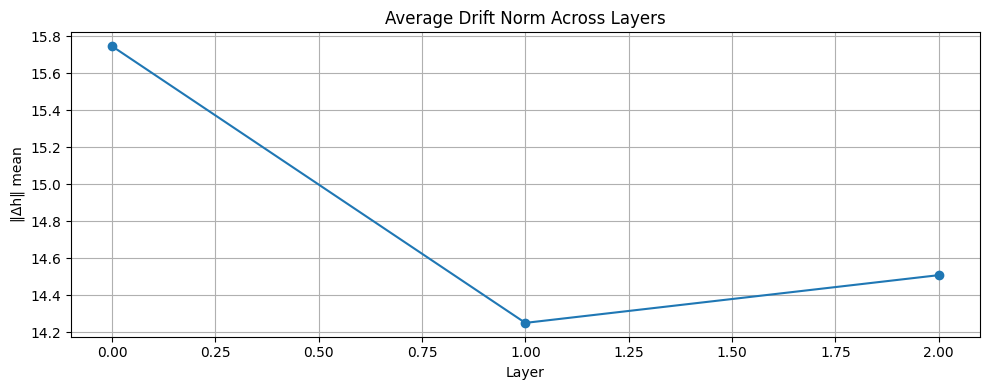

Jacobian rank (final token, projected): 41


In [73]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
'''
     def forward(self, idx, targets=None):
        device = idx.device
        b, T = idx.size()

        # forward the GPT model itself
        x = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)

        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            # if we are given some desired targets also calculate the loss
            logits = self.lm_head(x)

            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)

        else:
            # inference-time mini-optimization: only forward the lm_head on the very last position
            logits = self.lm_head(x[:, [-1], :]) # note: using list [-1] to preserve the time dim
            loss = None

        return logits, loss

'''


@torch.no_grad()
def compute_drift_trajectories(model, idx, pad_token_id=None):
    """
    Drift vectors Δh_l = h_{l+1} - h_l aligned to the shrinking time axis.
    idx: [B, T_visible]
    pad_token_id: pad token id to prepend once (?1 default=0 if None)
    returns: list of arrays, one per layer-gap, each shaped [B]
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx
    # forward the GPT model itself



    # token + pos emb
    x =norm( model.transformer.wte(tok))
    layers = []

    with torch.no_grad():

        for i, block in enumerate(model.transformer.h):
            x = block(x)
            layers.append(x.clone()) # store aligned outputs

    # compute drifts with alignment: previous tail matches current length
    drifts = []
    for i in range(len(layers) - 1):
        a = layers[i]
        b = layers[i + 1]
        a_aligned = a[:, -b.size(1):, :]
        d = (b - a_aligned)
        drifts.append(d.norm(dim=-1).mean(dim=-1).cpu().numpy())  # [B]
    return drifts

def effective_rank(J):
    s = np.linalg.svd(J, compute_uv=False)
    s = s[s > 1e-10]
    p = s / s.sum()
    return np.exp(-np.sum(p * np.log(p)))

def compute_jacobian_rank(model, idx, projection_dim=324, pad_token_id=None):
    """
    Rank of Jacobian d logits_proj(T_final) / d emb(T_input_last) with pad-once and shrink.
    idx: [B, T_visible]
    pad_token_id: pad token id to prepend once (?2 default=0 if None)
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx

    # embeddings with grad
    tok_emb =norm( model.transformer.wte(tok))
    emb = tok_emb
    def forward_emb(x):


        for i, block in enumerate(model.transformer.h):
            x = block(x)
        x = norm(x)
        logits =  model.lm_head(x)    # [B, T_out, V]
        return logits[:, -1, :projection_dim]  # final token after shrink, projected

    output = forward_emb(emb)         # [B, P]
    jac_rows = []
    for i in range(output.shape[-1]):
        go = torch.zeros_like(output)
        go[:, i] = 1.0
        gi = grad(output, emb, grad_outputs=go, retain_graph=True)[0]  # [B, T_all, C]
        jac_rows.append(gi[:, -1, :].detach().cpu().numpy().squeeze()) # grad w.r.t. last input step
    J = np.stack(jac_rows, axis=0)     # [P, C]
    return int(effective_rank(J))

def plot_drift(drift_norms):
    """
    Plot average drift norm per layer.
    """
    plt.figure(figsize=(10, 4))
    plt.plot([np.mean(d) for d in drift_norms], marker='o')
    plt.title("Average Drift Norm Across Layers")
    plt.xlabel("Layer")
    plt.ylabel("‖Δh‖ mean")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example usage
input_ids = torch.randint(0, model.config.vocab_size, (1, model.config.block_size)).to(device)

jac_rank = compute_jacobian_rank(model, input_ids)

drift_norms = compute_drift_trajectories(model, input_ids)
plot_drift(drift_norms)

print("Jacobian rank (final token, projected):", jac_rank)

In [74]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def collect_drift_matrix(model, idx, pad_token_id=None):
    """
    Build a drift matrix by stacking aligned per-layer deltas:
      Δ_l = h_{l+1} - tail_match(h_l)
    Tail-match aligns time since each block trims from the left.

    idx: [B, T_visible]
    pad_token_id: ?1 left-pad token id; default 0 if None
    returns: torch.FloatTensor [N, D] on CPU where N = sum_l B * T_l
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx

    # 2) embed like forward() does
    x = norm(model.transformer.wte(tok))
    # 3) collect per-block states (time shrinks each block)
    states = []
    with torch.no_grad():

        for i, block in enumerate(model.transformer.h):
            x = block(x)
            states.append(x.clone())

    # 4) aligned drifts: match tail of h_l to h_{l+1}
    drift_chunks = []
    for i in range(len(states) - 1):
        a = states[i]       # [B, T_a, C]
        b = states[i + 1]   # [B, T_b, C], T_b <= T_a
        a_aligned = a[:, -b.size(1):, :]     # tail-match
        d = (b - a_aligned).reshape(-1, b.size(-1))  # [B*T_b, C]
        drift_chunks.append(d.cpu())

    drift_matrix = torch.cat(drift_chunks, dim=0) if drift_chunks else torch.empty(0, x.size(-1))
    return drift_matrix  # [N, D] on CPU


def run_drift_pca(drift_matrix, k=40):
    """
    PCA on drift samples. drift_matrix can be torch.Tensor [N, D] (CPU or CUDA) or np.ndarray.
    """
    if isinstance(drift_matrix, torch.Tensor):
        drift_np = drift_matrix.detach().cpu().numpy()
    else:
        drift_np = np.asarray(drift_matrix)
    k = min(k, drift_np.shape[0], drift_np.shape[1])  # guard
    pca = PCA(n_components=k)
    pca.fit(drift_np)
    explained = pca.explained_variance_ratio_
    return explained, pca


def plot_explained_variance(explained):
    plt.figure(figsize=(8, 4))
    plt.plot(np.cumsum(explained) * 100, marker='o')
    plt.xlabel("Principal Component")
    plt.ylabel("Cumulative Variance Explained (%)")
    plt.title("Drift Trajectory PCA: Explained Variance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [75]:
from sklearn.mixture import GaussianMixture
import seaborn as sns

def get_projected_residuals(drift_matrix, pca):
    """
    Project Δh onto PCA space and get residuals.
    """
    proj = pca.transform(drift_matrix.numpy())
    recon = pca.inverse_transform(proj)
    residuals = drift_matrix.numpy() - recon
    return proj, residuals

def fit_gmm(proj_data, k=4):
    """
    Fit GMM to PCA-projected drift vectors to identify latent regimes.
    """
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=0)
    gmm.fit(proj_data)
    labels = gmm.predict(proj_data)
    return gmm, labels

def plot_gmm_clusters(proj_data, labels):
    """
    Plot GMM clustering over first 2 PCA components.
    """
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=proj_data[:, 0], y=proj_data[:, 1], hue=labels, palette="tab10", s=10)
    plt.title("Latent Regimes from Drift PCA (GMM Clusters)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


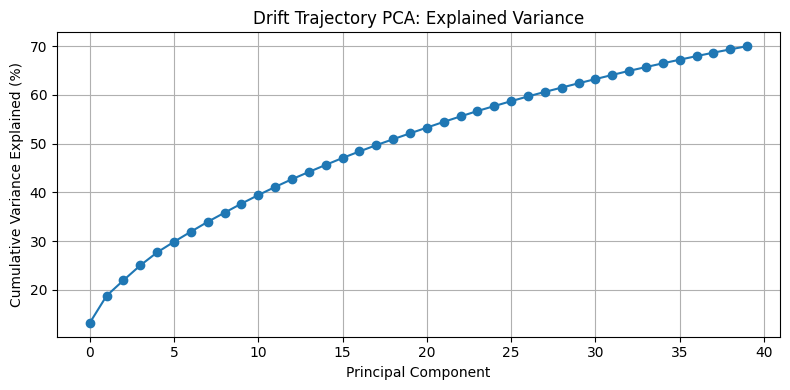

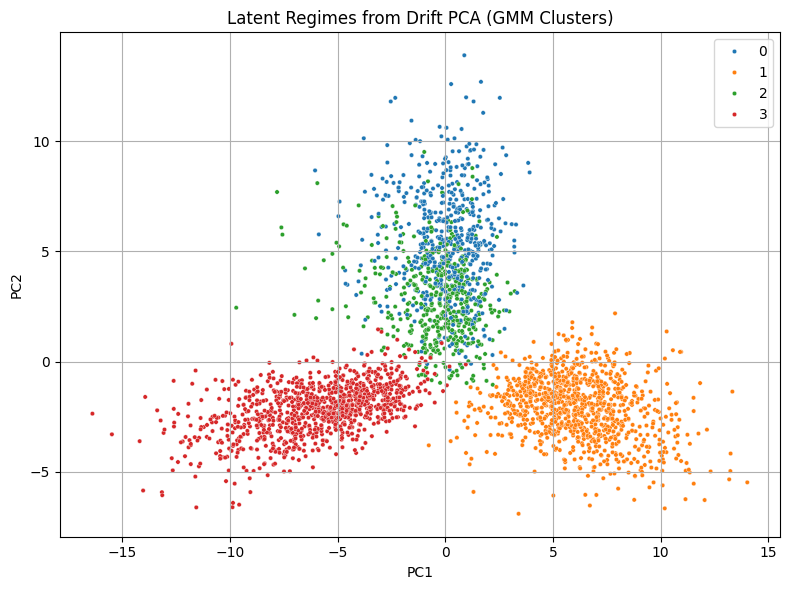

In [76]:
# Inputs
input_ids = torch.randint(0, model.config.vocab_size, (1, model.config.block_size)).to(device)

# Drift matrix
drift_matrix = collect_drift_matrix(model, input_ids)

# PCA and variance
explained, pca = run_drift_pca(drift_matrix, k=40)
plot_explained_variance(explained)

# Residuals and GMM regime fit
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=4)
plot_gmm_clusters(proj, labels)


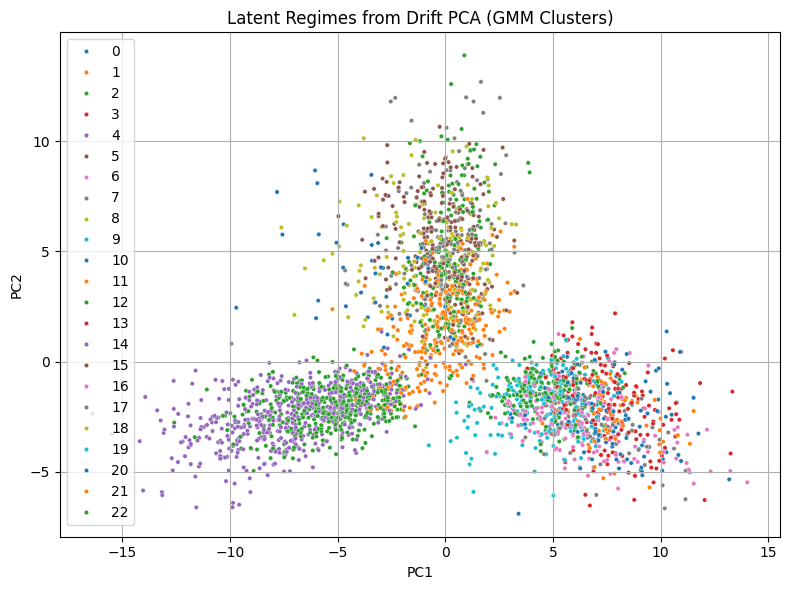

In [77]:
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=23)
plot_gmm_clusters(proj, labels)

In [ ]:
import torch

def analyze_logit_magnitude(model, loader):
    # Set model to eval to disable dropout/norm updates
    model.eval()

    # Extract one batch from the loader logic provided
    iterator = iter(loader)
    xb, yb = next(iterator)

    # Mimic the unwrapping from your training loop
    if isinstance(xb, list) or (isinstance(xb, torch.Tensor) and xb.dim() > 2):
        xb = xb[0]

    # Ensure context is on the correct device
    device = next(model.parameters()).device
    context = xb.to(device)

    print(f"Context shape: {context.shape}")

    with torch.no_grad():
        # Forward pass
        logits, _ = model(context)

        # Select the logits for the last token in the sequence
        # Shape: (Batch, Time, Vocab) -> select one batch, last time step
        last_logits = logits[0, -1, :]

        max_val = last_logits.max().item()
        min_val = last_logits.min().item()
        mean_val = last_logits.mean().item()
        spread = max_val - min_val

        print("--- Logit Explosion Check ---")
        print(f"Max Logit:   {max_val:.4f}")
        print(f"Min Logit:   {min_val:.4f}")
        print(f"Mean Logit:  {mean_val:.4f}")
        print(f"Spread:      {spread:.4f}")

        # Calculate the temperature required to return this to a normal variance (assuming ~10 spread is normal)
        print(f"Effective Temp needed to normalize: {spread / 10:.2f}")
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)

# Execute
analyze_logit_magnitude(model, train_loader)

Context shape: torch.Size([8, 1024])


In [ ]:
import random
import torch

def run_diagnostics(model, full_train_text, stoi, itos):
    print(f"--- 🧪 DIAGNOSTIC SUITE ---")

    # === TEST 1: The Verbatim Probe (Memory Check) ===
    # We grab a random sequence, feed the first half, and see if the model
    # perfectly reproduces the second half.

    seq_len = 128
    split = seq_len // 2
    samples = 5
    matches = 0

    print(f"\n[1] Verbatim Memorization Probe (n={samples})")
    print(f"    Condition: Temperature=0.00001 (Argmax proxy)")

    for i in range(samples):
        # Pick random slice
        start_idx = random.randint(0, len(full_train_text) - seq_len - 1)
        truth = full_train_text[start_idx : start_idx + seq_len]

        prompt_segment = truth[:split]
        target_segment = truth[split:]

        # Generate
        full_output = decode_sequence_char(
            model=model,
            stoi=stoi,
            itos=itos,
            prompt=prompt_segment,
            max_new_tokens=len(target_segment), # exact length match
            block_size=1024,
            temperature=1e-8 # Force greedy decoding
        )

        # Strip prompt to get just the generation
        # (Your function returns prompt + generation)
        generated_part = full_output[len(prompt_segment):]

        # Compare
        is_exact = (generated_part == target_segment)
        if is_exact: matches += 1

        status = "✅ MEMORY HIT" if is_exact else "❌ NO MATCH"
        print(f"\nSample {i+1}: {status}")
        print(f"Prompt:   {repr(prompt_segment)}")
        print(f"Expected: {repr(target_segment)}")
        print(f"Got:      {repr(generated_part)}")

    print(f"\nScore: {matches}/{samples}")
    if matches >= 4:
        print(">> RESULT: HIGH MEMORIZATION. Model is acting as a lookup table.")
    else:
        print(">> RESULT: LOW MEMORIZATION. Model is hallucinating/overfitting patterns.")

    # === TEST 2: The Adversarial Scaffold ===
    # We feed a format that looks like valid dialogue but uses tokens/names
    # that (likely) don't exist in the training set to break the lookup key.

    print(f"\n[2] Adversarial Scaffold Test")
    print("    Prompt: 'CYBERPUNK: The system is down. JULIET:'")

    scaffold = "CYBERPUNK: The system is down. JULIET:"

    adv_output = decode_sequence_char(
        model=model,
        stoi=stoi,
        itos=itos,
        prompt=scaffold,
        max_new_tokens=100,
        block_size=1024,
        temperature=1.0 # Normal sampling
    )

    print(f"    Result: {repr(adv_output[len(scaffold):])}")
    print("    Interpretation: If result is nonsense or reverts to 'ROMEO:', indexing failed.")
    print("                    If result creates a plausible Juliet line, it has generalized syntax.")

# Execute
# Assumes 'full_train' string is still in memory from your previous script.
# If not, reload it: full_train = open("babylm_10m_cleaned/shakespeare.txt").read() ...
run_diagnostics(model, full_train, stoi, itos)

--- 🧪 DIAGNOSTIC SUITE ---

[1] Verbatim Memorization Probe (n=5)
    Condition: Temperature=0.00001 (Argmax proxy)

Sample 1: ❌ NO MATCH
Prompt:   'en we drink we die.\n\nLUCIO:\nIf could speak so wisely under an ar'
Expected: 'rest, I would\nsend for certain of my creditors: and yet, to say\n'
Got:      't the world,\nAnd the time of the sea of the state of the world,\n'

Sample 2: ❌ NO MATCH
Prompt:   "-general to sue\nHis livery, and deny his offer'd homage,\nYou plu"
Expected: 'ck a thousand dangers on your head,\nYou lose a thousand well-dis'
Got:      'ck the sense of his house of his house,\nAnd the sun of his house'

Sample 3: ❌ NO MATCH
Prompt:   "ind\nI' the part that is at mercy? Five times, Marcius,\nI have fo"
Expected: 'ught with thee: so often hast thou beat me,\nAnd wouldst do so, I'
Got:      'rgot to the prince of the prince,\nAnd then the state of the stat'

Sample 4: ❌ NO MATCH
Prompt:   "ALUS:\nHe's in the right. Constable, what say you to it?\n\nELBOW:\n"
Expecte

In [ ]:
#save the model
PATH = "tinyshakespeare.pt"
torch.save(model.state_dict(), PATH)
